<a href="https://colab.research.google.com/github/eemaansheikh/Data_Science_2025/blob/main/EemaanSheikh_MultLinExercises%20(Stats).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install bambi

In [6]:
from google.colab import files
from google.colab.output import eval_js
import io
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import graphviz as gv
import arviz as az
import pymc as pm
import bambi as bmb

## Exercises

You may use whatever resources you want to complete these exercises, so long as you cite your sources and the use of AI.

I recommend copying and pasting from the examples I did [here](https://github.com/thedarredondo/data-science-fundamentals/blob/main/FastTrack/IntroMultLinSF.ipynb); giving you something to copy and paste from was half my intent in writing that lesson.

**Task1**

Get the [penguins data from my github page](https://github.com/thedarredondo/data-science-fundamentals/blob/main/Data/penguins.csv) into this colab document.

I suggest downloading the csv, and then using the code from [notes document](https://github.com/thedarredondo/data-science-fundamentals/blob/main/FastTrack/IntroMultLinSF.ipynb) to upload it into this jupyter notebook.

In [7]:
url="https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/penguins.csv"
penguins = pd.read_csv(url).dropna()

In [8]:
penguins

,species,island,bill_length,bill_depth,flipper_length,body_mass,sex,year
0,Adelie,Torgersen,3.91,1.87,18.1,3.750,male,2007
1,Adelie,Torgersen,3.95,1.74,18.6,3.800,female,2007
2,Adelie,Torgersen,4.03,1.80,19.5,3.250,female,2007
4,Adelie,Torgersen,3.67,1.93,19.3,3.450,female,2007
5,Adelie,Torgersen,3.93,2.06,19.0,3.650,male,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,5.58,1.98,20.7,4.000,male,2009
340,Chinstrap,Dream,4.35,1.81,20.2,3.400,female,2009
341,Chinstrap,Dream,4.96,1.82,19.3,3.775,male,2009
342,Chinstrap,Dream,5.08,1.90,21.0,4.100,male,2009


**Task2**

Make a pair plot with the penguins data and describe the scatter plots. Make sure to describe any patterns.

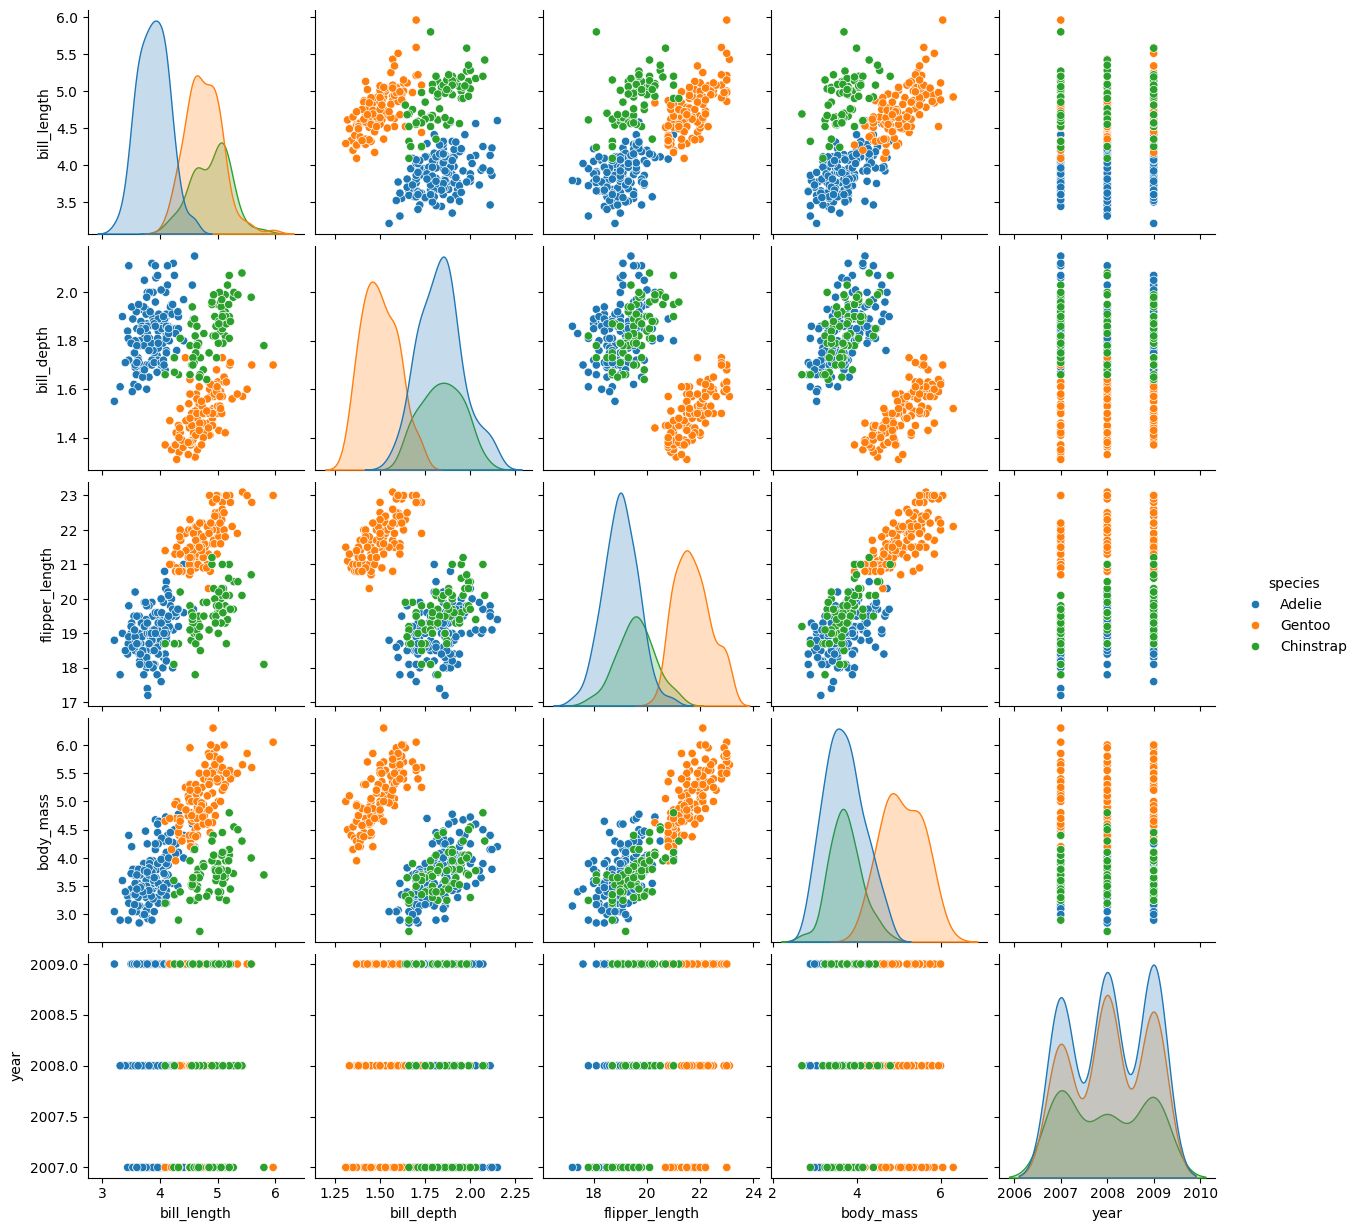

In [ ]:
sns.pairplot(penguins, hue = "species")

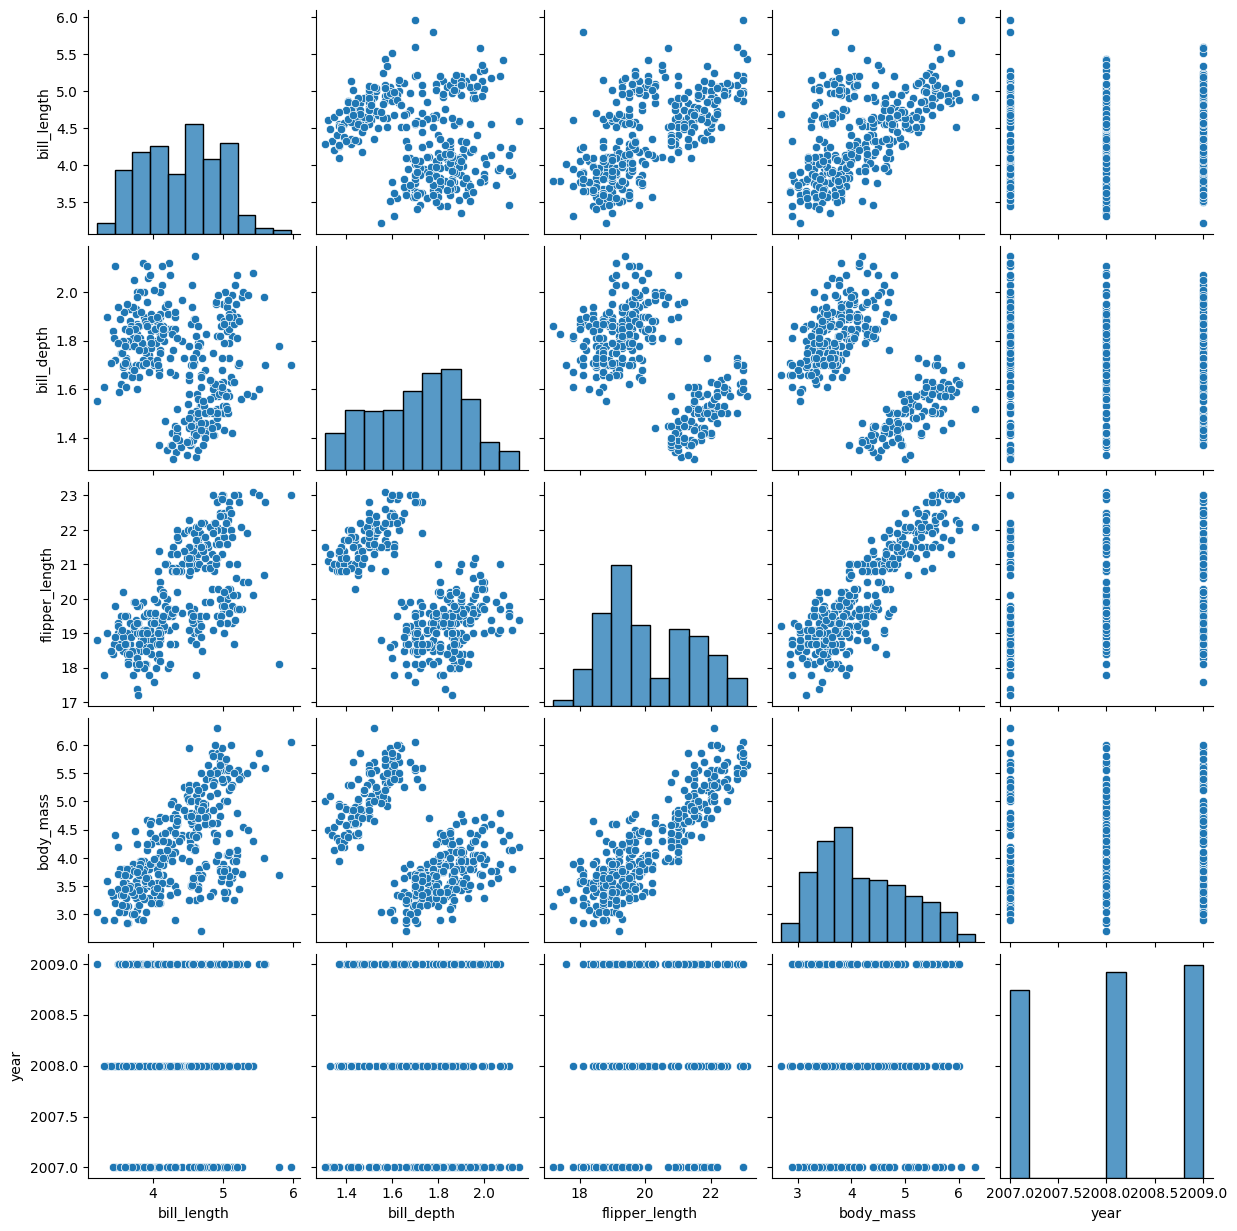

In [ ]:
sns.pairplot(penguins)

**Task3**

Make a causal diagram corresponding to the penguins data. Remember to include the species variable, even though it likely didn't show up in your pair plot.

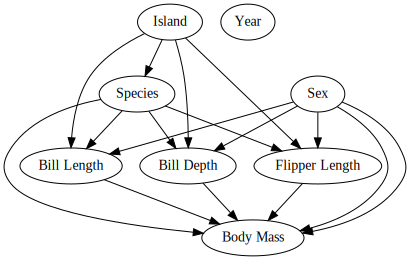

In [ ]:
b_dag = gv.Digraph(name="Penguins")

b_dag.node('L','Bill Length')
b_dag.node('D','Bill Depth')
b_dag.node('F','Flipper Length')
b_dag.node('B','Body Mass')
b_dag.node('Y','Year')
b_dag.node('S','Sex')
b_dag.node('I','Island')
b_dag.node('P','Species')

b_dag.edges(['LB','FB','SB','PL','PD','PF','IP','SB','SL','SD','SF','IL','ID','IF','PB','DB'])

b_dag

**Task4**

Create a Bayesian generalized linear model (GLM) to represent and test your causal diagram.

Then, conduct both types of posterior predictve check, and use them to comment on the model's fit. Note that you may want to make several plots here.

You may use another model type if want--[such as BART](https://github.com/thedarredondo/data-science-fundamentals/blob/main/Unit8/Unit8NotesSF.ipynb)--so long as it is Bayesian, and it represents your causal diagram.

 --- Posterior Predictive Check ---

In [9]:
model_penguins = bmb.Model("body_mass ~ bill_depth + flipper_length + bill_length:bill_depth + bill_depth:flipper_length + bill_length:flipper_length", data = penguins)

In [ ]:
model_penguins

In [ ]:
idata_penguins = model_penguins.fit(idata_kwargs={"log_likelihood":True})

In [18]:
model_penguins.predict(idata_penguins, kind="response")

<Axes: xlabel='body_mass'>

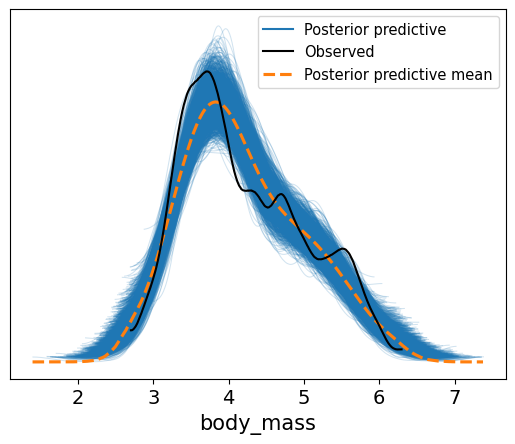

In [19]:
az.plot_ppc(idata_penguins)

--- Scatterplot PPC ---

array([[<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'Intercept'}>],
       [<Axes: title={'center': 'bill_depth'}>,
        <Axes: title={'center': 'bill_depth'}>],
       [<Axes: title={'center': 'bill_depth:flipper_length'}>,
        <Axes: title={'center': 'bill_depth:flipper_length'}>],
       [<Axes: title={'center': 'bill_length'}>,
        <Axes: title={'center': 'bill_length'}>],
       [<Axes: title={'center': 'bill_length:bill_depth'}>,
        <Axes: title={'center': 'bill_length:bill_depth'}>],
       [<Axes: title={'center': 'bill_length:flipper_length'}>,
        <Axes: title={'center': 'bill_length:flipper_length'}>],
       [<Axes: title={'center': 'flipper_length'}>,
        <Axes: title={'center': 'flipper_length'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>],
       [<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'mu'}>]],
      dtype=object)

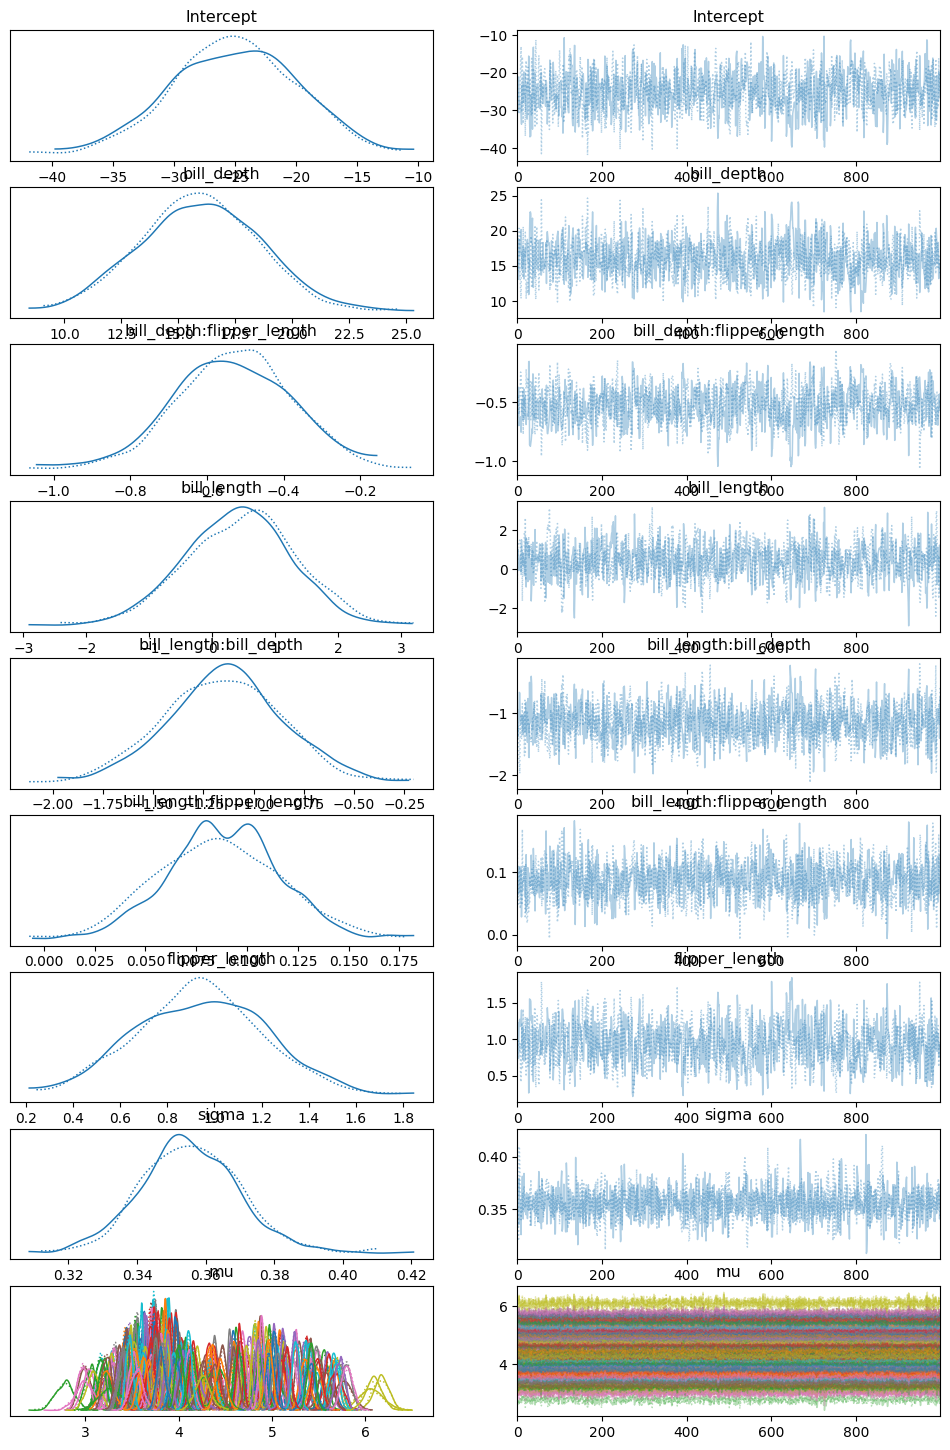

In [ ]:
az.plot_trace(idata_penguins)

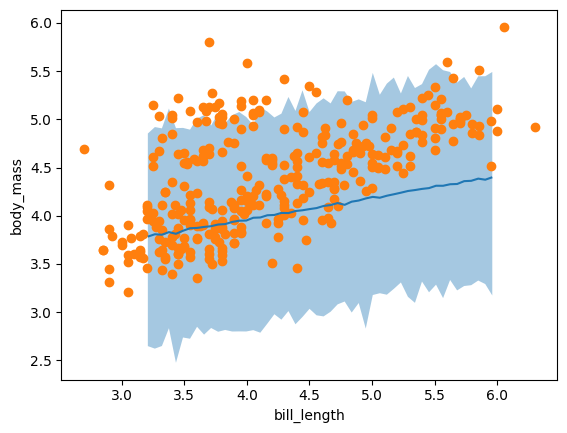

In [ ]:
bmb.interpret.plot_predictions(model_penguins, idata_penguins, ["bill_length"], pps=True, prob=0.998)
plt.scatter(penguins.body_mass, penguins.bill_length)

In [ ]:
import bambi as bmb
model_penguins_interaction = bmb.Model("`body_mass` ~ `flipper_length` + `bill_depth` + 'bill_length' + `flipper_length`:`bill_depth` + `flipper_length`:`bill_length` + `bill_length`:`bill_depth`" , data=penguins)
#create the model's inference data
idata_penguins_interaction = model_penguins_interaction.fit(idata_kwargs={'log_likelihood': True})

(<Figure size 1100x1300 with 1 Axes>,
 array([<Axes: xlabel='flipper_length', ylabel='body_mass'>], dtype=object))

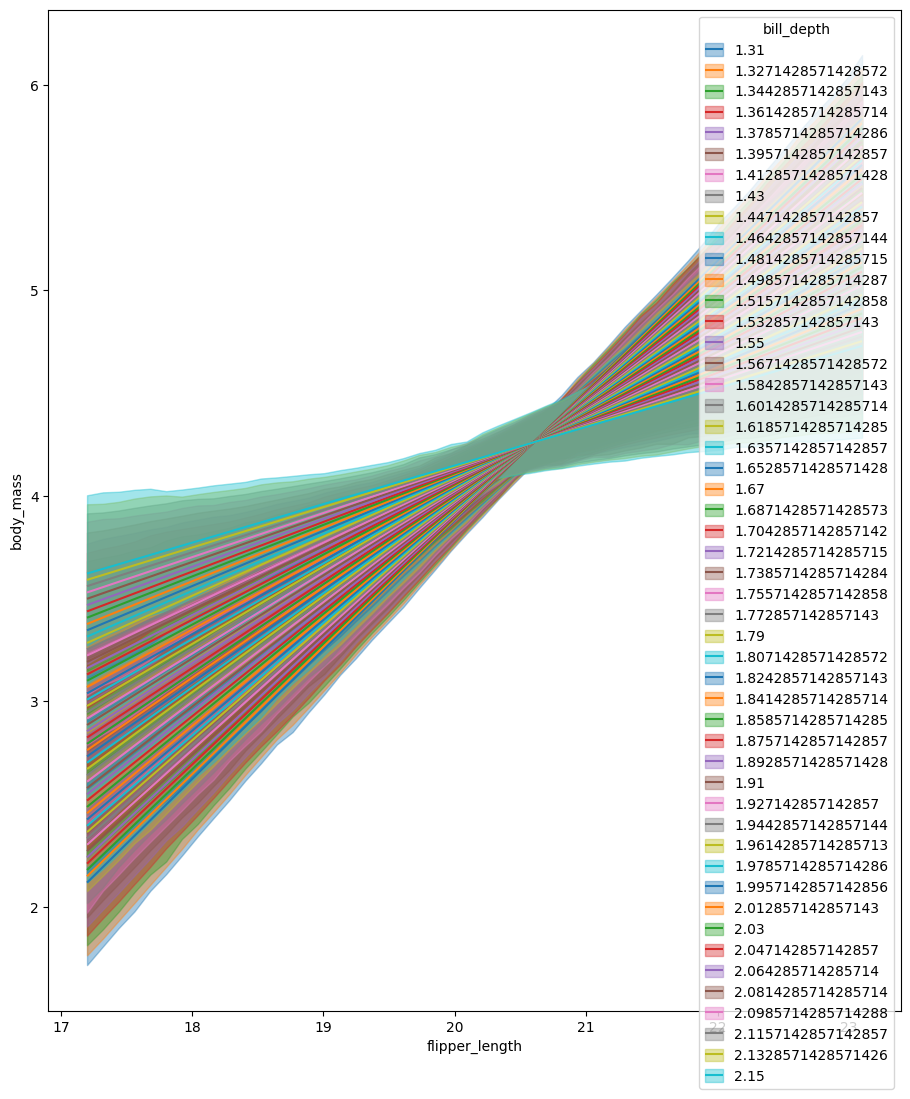

In [13]:
bmb.interpret.plot_predictions(model_penguins_interaction,
                               idata_penguins_interaction,
                               ["flipper_length","bill_depth",],
                               fig_kwargs={"figsize":(11, 13)})

**Task5**

Create as many other models as you need to test your causal hypotheses.

Then, "test" those causal hypotheses using the az.compare and az.plot_compare() functions.

In [ ]:
model_allnointer = bmb.Model("body_mass ~ bill_length + flipper_length + bill_depth", data = penguins)
idata_allnointer = model_allnointer.fit(idata_kwargs={"log_likelihood":True})
#all

In [ ]:
model_billlength = bmb.Model("body_mass ~ bill_length", data = penguins)
idata_billlength = model_billlength.fit(idata_kwargs={"log_likelihood":True})
#bill_length only

In [ ]:
model_flipperlength = bmb.Model("body_mass ~ flipper_length", data = penguins)
idata_flipperlength = model_flipperlength.fit(idata_kwargs={"log_likelihood":True})
#flipper_length only

In [ ]:
model_billdepth = bmb.Model("body_mass ~ bill_depth", data = penguins)
idata_billdepth = model_billdepth.fit(idata_kwargs={"log_likelihood":True})
#billdepth only

In [ ]:
model_interfl = bmb.Model("body_mass ~ bill_length + flipper_length + bill_depth + flipper_length:bill_length + flipper_length:bill_depth", data = penguins)
idata_interfl = model_interfl.fit(idata_kwargs={"log_likelihood":True})
#all variables + interactions with flipper_length

In [ ]:
model_interbd = bmb.Model("body_mass ~ bill_length + flipper_length + bill_depth + bill_depth:bill_length + flipper_length:bill_depth", data = penguins)
idata_interbd = model_interbd.fit(idata_kwargs={"log_likelihood":True})
#all variables + interactions with bill_depth

In [ ]:
model_interbl = bmb.Model("body_mass ~ bill_length + flipper_length + bill_depth + flipper_length:bill_length + bill_length:bill_depth", data = penguins)
idata_interbl = model_interbl.fit(idata_kwargs={"log_likelihood":True})
#all variables + interactions with bill_length

In [24]:
cmp_df = az.compare({"My Hyp. (All Variables + Interactions)":idata_penguins,"Bill Length + Bill Depth + Flipper Length":idata_allnointer,"Flipper Length":idata_flipperlength,"Bill Depth":idata_billdepth, "Bill Length":idata_billlength, "Interactions with Flipper Length":idata_interfl, "Interactions with Bill Depth":idata_interbd, "Interactions with Bill Length":idata_interbl})


In [25]:
cmp_df


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
My Hyp. (All Variables + Interactions),0,-130.318867,6.085852,0.000000,1.000000e+00,13.238013,0.000000,False,log
Interactions with Bill Depth,1,-134.771701,6.262751,4.452835,0.000000e+00,13.220009,2.789576,False,log
Interactions with Flipper Length,2,-136.971376,6.096271,6.652510,0.000000e+00,13.231977,3.082739,False,log
Interactions with Bill Length,3,-138.223985,5.992249,7.905119,0.000000e+00,13.347314,3.669229,False,log
Flipper Length,4,-163.723947,2.862574,33.405080,0.000000e+00,13.039189,6.457511,False,log
Bill Length + Bill Depth + Flipper Length,5,-164.214176,4.461285,33.895309,0.000000e+00,13.082826,6.474435,False,log
Bill Length,6,-331.664509,2.807348,201.345642,0.000000e+00,11.422110,13.674982,False,log
Bill Depth,7,-360.580650,2.348470,230.261783,7.044605e-10,11.190084,14.537894,False,log


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

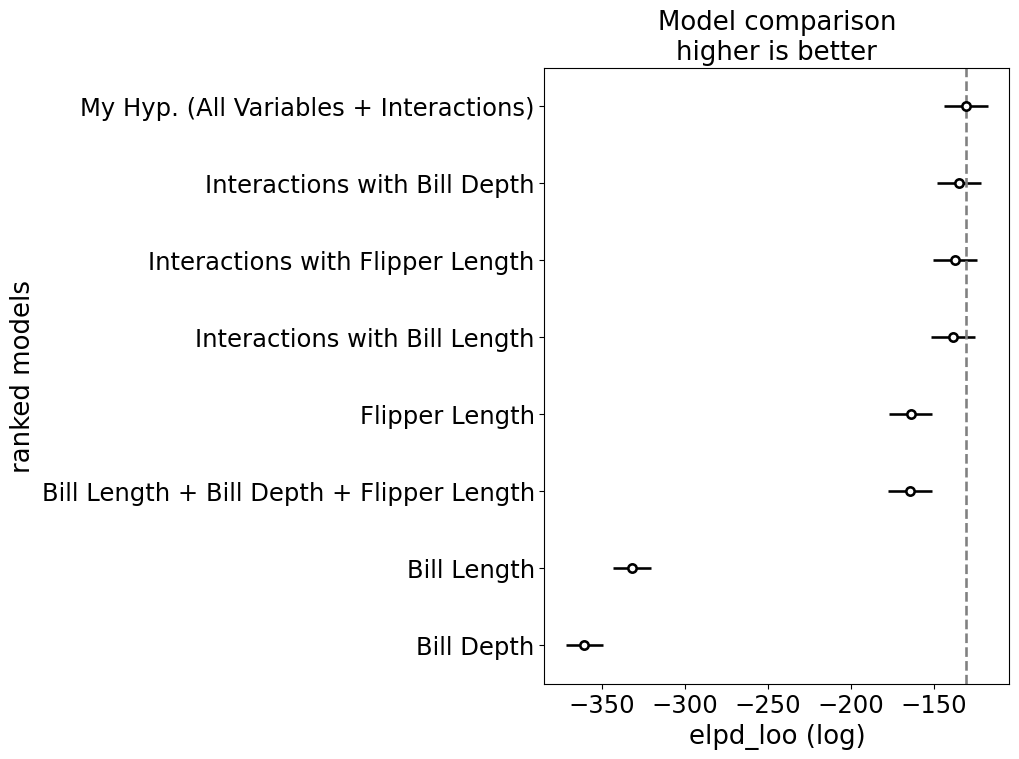

In [26]:
az.plot_compare(cmp_df)


**Task6**

Answer the following:

- Which variables were most important?

- Was that surprising? Why?

- Did the model representing your causal diagram perform worse or better than other models?

- What did you learn about the data--and about penguins--from your models?

Flipper length seems to be the most important individual predictor since it had a higher elpd_loo than bill length and bill depth individually. Interactions between two variables did better than any individual predictor, and the best predictor was my hypothesis, which was all three indiviual predictors and interactions. In other words, the model representing my causal diagram (My Hyp.) outperformed the other models.

I was surprised to see that My Hypothesis model was better than the only additive Bill Length + Bill Depth + Flipper Length. This seems to indicate that body mass is determined not just by all three physical measurements, but also how all of them interact together. I didn't expect the interactions to have so much of an impact on the body mass and was surprised to see such a difference in rank (1 vs 6).

From my data, it can be seen that body mass is not well predicted by its individual components (which ranked low on the elpd_loo model), but rather by accounting for the interactions they have with each other.
